# Análise de Distância e Agrupamento (Clustering) de Clientes

Objetivo: aplicação de estudos em análise de dados com agrupamento e análise de distância utilizando a problemática de segmentar clientes com base em seu histórico de compras (Recência, Frequência e Valor). É usado algoritmo de **Agrupamento Hierárquico (Método de Ward)** para encontrar clientes com comportamentos semelhantes.

In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Transformação
from sklearn.preprocessing import PowerTransformer

# Algoritmos de Clusterização e Distâncias
from scipy.spatial import distance
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")

## 1. Carga e Preparação dos Dados

In [193]:
# 1. Carregando as bases disponíveis
df_vendas = pd.read_csv('bases/fato_vendas.csv')
df_clientes = pd.read_csv('bases/dim_clientes.csv')
df_interacoes = pd.read_csv('bases/fato_interacoes.csv')

# 2. Agrupando as Vendas para gerar o RFM
rfm = df_vendas.groupby('id_cliente').agg(
    recencia_dias=('dias_atras_compra', 'min'), 
    frequencia=('id_venda', 'count'),           
    valor_venda=('valor_venda', 'sum')          
).reset_index()

# 3. Tratando as Interações (Mantendo o VOLUME real, sem binarizar)
interacoes_agg = pd.crosstab(df_interacoes['id_cliente'], df_interacoes['tipo_interacao']).reset_index()
interacoes_agg.columns.name = None # Limpeza estética do eixo

# 4. Consolidando tudo na dim_clientes final (Uso do LEFT JOIN)
dim_clientes = df_clientes.merge(rfm, on='id_cliente', how='inner')
dim_clientes = dim_clientes.merge(interacoes_agg, on='id_cliente', how='left')

# Preenche vazios (clientes compradores que não tiveram interação digital rastreada) com 0
dim_clientes.fillna(0, inplace=True)

dim_clientes.head()

,id_cliente,dias_desde_cadastro,recencia_dias,frequencia,valor_venda,clique_ad,visita_organica
0,1,192,14,3,1493.29,0.0,3.0
1,2,525,247,1,616.41,2.0,2.0
2,3,360,20,1,74.67,0.0,1.0
3,4,196,45,2,773.21,0.0,1.0
4,5,161,8,2,689.96,0.0,4.0


## 2. Normalização dos Dados (Feature Scaling)
Como variáveis como `recencia_dias` possuem valores atípicos (outliers) e assimetria, e `frequencia` está em uma escala muito menor, **é obrigatório normalizar** os dados para que todos tenham o mesmo peso no algoritmo de distância.

Vamos usar o `PowerTransformer` para aproximar as distribuições de uma curva normal.

In [194]:
# Selecionando todas as variáveis disponíveis para o cluster, removendo apenas a chave primária
features = dim_clientes.columns.drop('id_cliente').tolist()
dados_cluster = dim_clientes[features]

# Aplicando o PowerTransformer configurado para dados de contagem e centralização
pt = PowerTransformer(method='yeo-johnson', standardize=True)
clientes_pad = pt.fit_transform(dados_cluster)

# Convertendo de volta para DataFrame apenas para facilitar a visualização
clientes_pad_df = pd.DataFrame(clientes_pad, columns=features)
clientes_pad_df.head()

,dias_desde_cadastro,recencia_dias,frequencia,valor_venda,clique_ad,visita_organica
0,-1.114459,-0.718868,1.071025,1.350381,-1.136598,0.927213
1,0.712435,1.502032,-1.101343,0.514179,0.524433,0.449407
2,-0.127165,-0.458047,-1.101343,-1.417637,-1.136598,-0.224823
3,-1.088521,0.155587,0.341884,0.726978,-1.136598,-0.224823
4,-1.321286,-1.112003,0.341884,0.619896,-1.136598,1.297503


## 3. Agrupamento Hierárquico (Método de Ward)
O método de Ward une os grupos de forma a minimizar o aumento da variância (distância) em cada passo. Vamos criar a matriz de ligação (linkage) e visualizar a árvore gerada (Dendrograma).

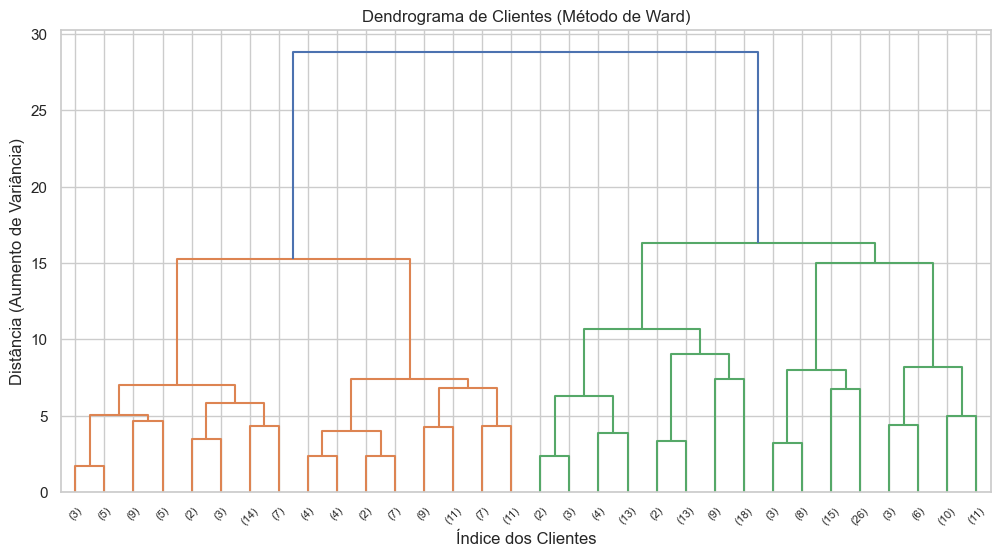

In [195]:
# Criando a matriz de ligação usando o método de Ward
matriz_ward = linkage(clientes_pad, method='ward')

# Desenhando o Dendrograma
plt.figure(figsize=(12, 6))
plt.title('Dendrograma de Clientes (Método de Ward)')
plt.xlabel('Índice dos Clientes')
plt.ylabel('Distância (Aumento de Variância)')

# truncate_mode='level' ajuda a visualizar melhor limitando a profundidade da árvore desenhada
dendrogram(matriz_ward, truncate_mode='level', p=4) 
plt.show()

In [ ]:
# N é o número total de linhas na sua base (clientes)
N = len(clientes_pad)
t = 3

# A matriz_ward armazena as fusões em ordem crescente de altura (Y)
# A fusão que define o limite para t clusters está no índice (N - t - 1)
y_inferior = matriz_ward[N - t - 1, 2]
y_superior = matriz_ward[N - t, 2]

print(f"Para ter exatamente {t} clusters, o corte de Y (distância) deve estar entre:")
print(f" > {y_inferior:.4f}  e  <= {y_superior:.4f}")

Para ter exatamente 3 clusters, o corte de Y (distância) deve estar entre:
 > 15.2658  e  <= 16.3074


## 4. Definição e Atribuição dos Clusters
Neste passo, faremos o corte manual do dendrograma. Vamos manter a definição de 3 clusters usando `criterion='maxclust'`. O algoritmo descerá pelo dendrograma até formar exatamente 3 grandes grupos.

In [196]:
# Cortando a árvore para formar exatamente 3 clusters
dim_clientes['cluster_designado'] = fcluster(matriz_ward, t=3, criterion='maxclust')

# Analisando o tamanho de cada cluster formado
distribuicao_clusters = dim_clientes['cluster_designado'].value_counts().sort_index()
print("Distribuição de clientes por cluster:\n", distribuicao_clusters)

# Analisando a média de cada variável por cluster para entender o PERFIL de cada grupo
perfil_clusters = dim_clientes.groupby('cluster_designado')[features].mean()
display(perfil_clusters)

Distribuição de clientes por cluster:
 cluster_designado
1    103
2     64
3     82
Name: count, dtype: int64


,dias_desde_cadastro,recencia_dias,frequencia,valor_venda,clique_ad,visita_organica
cluster_designado,,,,,,
1,369.650485,23.252427,1.922330,151.031068,3.097087,0.679612
2,359.875000,129.656250,1.171875,520.317500,0.578125,2.406250
3,463.353659,101.073171,2.768293,1233.920244,0.829268,2.524390
